## Best Optimization CV - Employer Bee Algo 3 + Onlooker Bee Algo 2

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Optimization"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_relm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_relm_cv.employed_bee_apply_algo3()
abc_relm_cv.onlooker_bee_apply_algo2()

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_relm_cv, x_train, y_train, x_test, y_test)
results_df.describe()

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.776563,0.784190,0.766667,0.773506,0.786458,0.773699,0.769101,0.776563,0.555397,55.500000
std,0.033625,0.042002,0.059027,0.042731,0.052602,0.036863,0.048712,0.033625,0.067467,8.803408
min,0.703125,0.705882,0.656250,0.685714,0.687500,0.688525,0.668790,0.703125,0.408047,41.000000
25%,0.753906,0.757576,0.726562,0.740132,0.750000,0.757837,0.738070,0.753906,0.514648,48.250000
50%,0.781250,0.777722,0.781250,0.774194,0.781250,0.771712,0.775296,0.781250,0.565274,55.500000
75%,0.796875,0.812500,0.812500,0.810988,0.812500,0.804478,0.811238,0.796875,0.595792,62.750000
max,0.828125,0.888889,0.843750,0.838710,0.906250,0.830769,0.838509,0.828125,0.664411,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_F1-Score.png


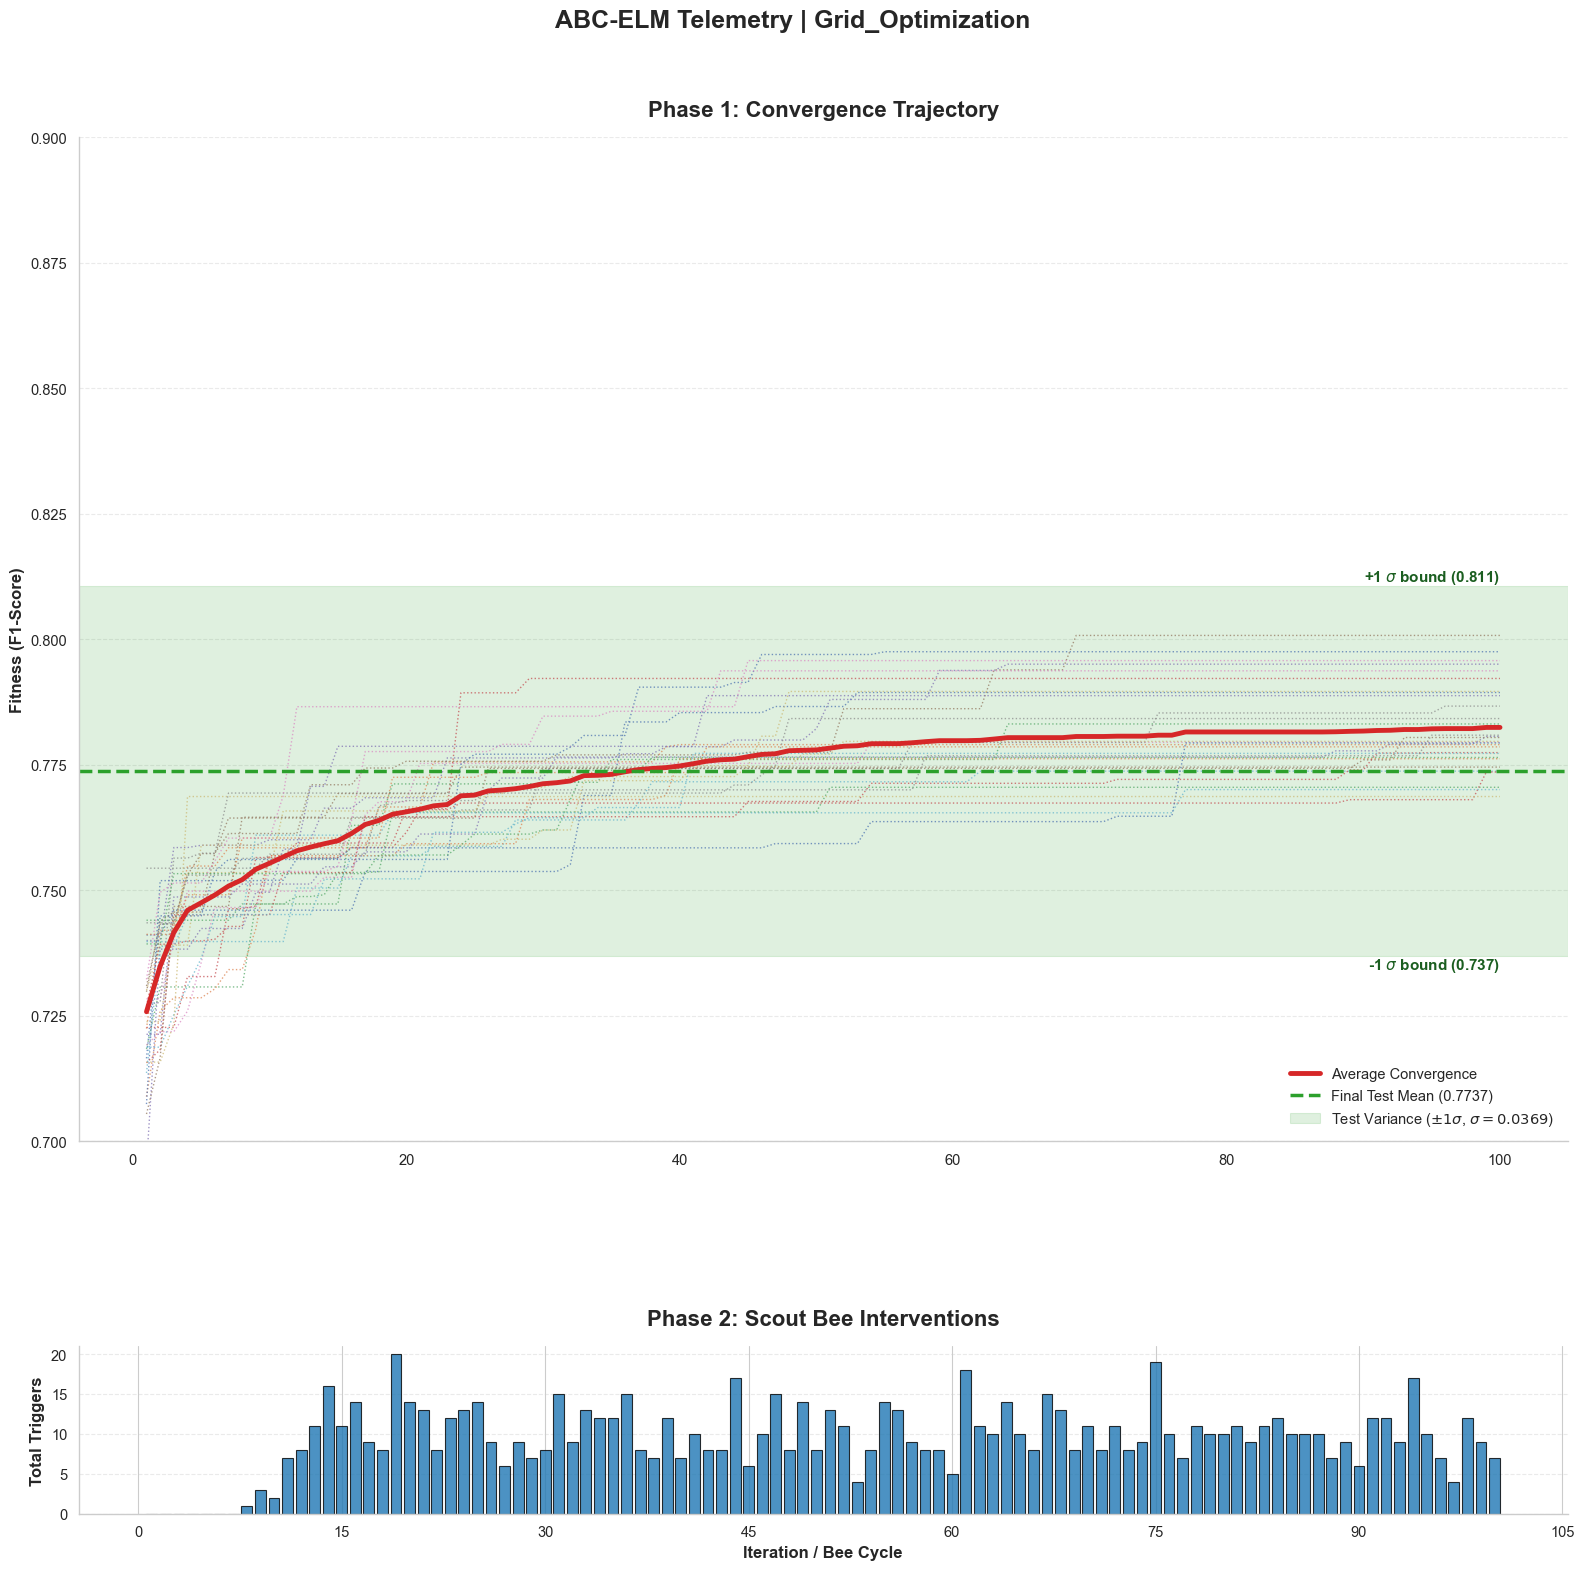

In [7]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [8]:
# GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
# GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
# GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')